# Run Multimodal M3Resp Workflow

Edit the file paths and settings in the configuration cell, then run the notebook from top to bottom.

In [22]:
from __future__ import annotations

import sys
from pathlib import Path
from typing import Any


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "m3resp").exists():
            return candidate
    raise RuntimeError("Could not find the m3resp repository root. Start Jupyter from the repo or notebooks folder.")


REPO_ROOT = find_repo_root()
ORG_ROOT = REPO_ROOT.parent

for path in [
    REPO_ROOT / "src",
    ORG_ROOT / "eitprocessing",
]:
    if path.exists() and str(path) not in sys.path:
        sys.path.insert(0, str(path))

REPO_ROOT

PosixPath('/home/mahyart/Desktop/github_repos/m3resp-org/m3resp')

In [23]:
from m3resp import M3Session
from m3resp.adapters import EITProcessingAdapter, ReSurfEMGAdapter

## Configuration

In [24]:
EIT_FILE = Path("/home/mahyart/Desktop/github_repos/m3resp-org/m3resp/data/source/draeger_synthetic_draeger_20Hz.bin")
EMG_FILE = REPO_ROOT / "data" / "source" / "emg_data_synth_quiet_breathing.Poly5"
EIT_VENDOR = "draeger"  # supported: "draeger", "timpel", "sentec", "simulated"

EMG_CHANNEL = 0
EMG_HIGH_PASS_HZ = 80
EMG_LOW_PASS_HZ = None
EMG_ENVELOPE_WINDOW_SECONDS = 0.5
EMG_MIN_BREATH_WIDTH_SECONDS = 1.0
MANUAL_OFFSET_SECONDS = 0.0
OUTPUT_DIR = REPO_ROOT / "output" / "multimodal-summary"

## ReSurfEMG Helper Functions

In [25]:
def load_emg(path: str, **kwargs: Any) -> dict[str, Any]:
    """Load an EMG file with ReSurfEMG's generic converter."""

    from resurfemg.data_connector.converter_functions import load_file

    array, dataframe, metadata = load_file(path, **kwargs)
    return {
        "array": array,
        "dataframe": dataframe,
        "metadata": metadata,
    }


def preprocess_emg(
    recording: dict[str, Any],
    channel: int = EMG_CHANNEL,
    high_pass_hz: float = EMG_HIGH_PASS_HZ,
    low_pass_hz: float | None = EMG_LOW_PASS_HZ,
    envelope_window_seconds: float = EMG_ENVELOPE_WINDOW_SECONDS,
) -> dict[str, Any]:
    """Band-pass one EMG channel and compute an ARV envelope."""

    import numpy as np
    from resurfemg.preprocessing.envelope import full_rolling_arv
    from resurfemg.preprocessing.filtering import emg_bandpass_butter

    metadata = dict(recording["metadata"])
    fs = float(metadata["fs"])
    array = recording["array"]
    raw = np.asarray(array[channel], dtype=float)

    if low_pass_hz is None:
        low_pass_hz = min(fs / 2 * 0.95, 500)

    filtered = emg_bandpass_butter(
        emg_raw=raw,
        high_pass=high_pass_hz,
        low_pass=low_pass_hz,
        fs_emg=fs,
    )
    envelope_window_samples = max(1, int(envelope_window_seconds * fs))
    envelope = full_rolling_arv(filtered, envelope_window_samples)

    return {
        **recording,
        "channel": channel,
        "fs": fs,
        "raw_channel": raw,
        "filtered": filtered,
        "envelope": envelope,
        "filter": {
            "high_pass_hz": high_pass_hz,
            "low_pass_hz": low_pass_hz,
            "envelope_window_seconds": envelope_window_seconds,
        },
    }


def detect_emg_breaths(
    processed_emg: dict[str, Any],
    min_breath_width_seconds: float = EMG_MIN_BREATH_WIDTH_SECONDS,
    half_window_seconds: float = 0.5,
    **kwargs: Any,
) -> list[dict[str, Any]]:
    """Detect EMG breath peaks and convert them to M3Resp breath rows."""

    from resurfemg.postprocessing.event_detection import detect_emg_breaths

    fs = float(processed_emg["fs"])
    envelope = processed_emg["envelope"]
    min_width_samples = max(1, int(min_breath_width_seconds * fs))
    half_window_samples = max(1, int(half_window_seconds * fs))

    peak_indices = detect_emg_breaths(
        emg_env=envelope,
        min_peak_width_s=min_width_samples,
        **kwargs,
    )

    events = []
    for peak_index in peak_indices:
        start_index = max(0, int(peak_index) - half_window_samples)
        end_index = min(len(envelope) - 1, int(peak_index) + half_window_samples)
        events.append(
            {
                "start_time": start_index / fs,
                "end_time": end_index / fs,
                "peak_time": int(peak_index) / fs,
                "source": "resurfemg.detect_emg_breaths",
                "metadata": {
                    "start_index": start_index,
                    "peak_index": int(peak_index),
                    "end_index": end_index,
                    "channel": processed_emg["channel"],
                },
            }
        )

    return events

## Run Workflow

In [26]:
session = M3Session(
    eit_adapter=EITProcessingAdapter(),
    emg_adapter=ReSurfEMGAdapter(loader=load_emg),
)

session.load_eit(EIT_FILE, vendor=EIT_VENDOR)
session.load_emg(EMG_FILE, verbose=False)

session.preprocess_eit()
session.preprocess_emg(preprocess=preprocess_emg)
session.detect_emg_breaths(detector=detect_emg_breaths)

session.align_modalities(
    method="manual_offset",
    offset_seconds=MANUAL_OFFSET_SECONDS,
)
session.export_summary(OUTPUT_DIR)

session

## Visualize Output

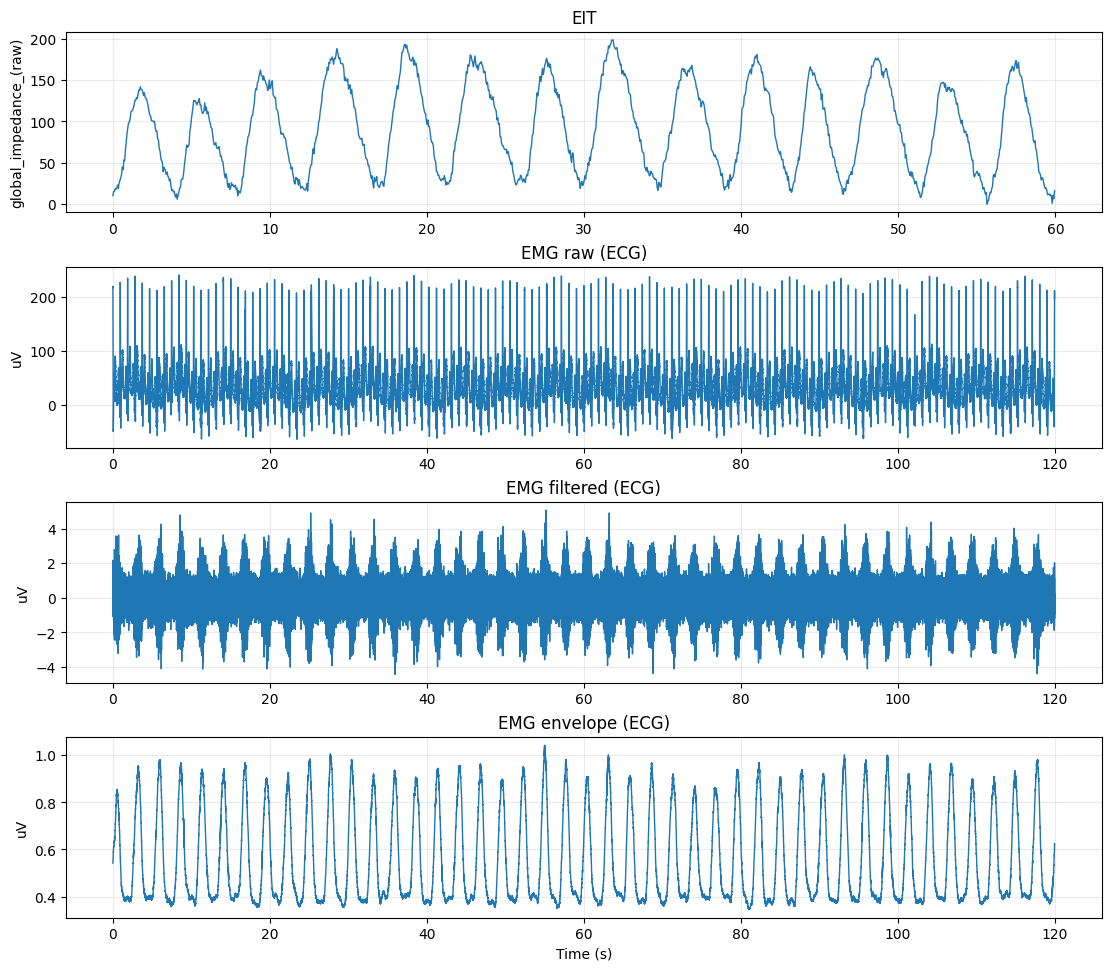

In [27]:
from m3resp.visualization import plot_session_overview

fig = plot_session_overview(session, max_seconds=120)
fig.savefig(OUTPUT_DIR / "overview.png", dpi=150)